# Applications to many-body systems: six electrons

Executable companion to chapter 16.

Every method in this book has now been developed, and every one has been tested
on a system chosen to make it easy.  Hartree-Fock, MBPT and coupled cluster were
applied in chapter 11 to a quantum dot in a finite oscillator basis; variational
and diffusion Monte Carlo were applied in chapters 13-15 to *two* electrons in
the same trap, where the trial function is nodeless and no determinant is needed.

Here all five meet on six electrons in a two-dimensional parabolic trap.  Six is
the smallest number for which none of the simplifications survive: the
determinant is real, the trial function has nodes, the basis-set methods are not
converged, and there is no exact answer -- only five methods that fail
differently, and published benchmarks.

The trial function is Slater-Jastrow,

$$
\Psi_T(\mathbf R,\boldsymbol\sigma) = |D_\uparrow|\,|D_\downarrow|\,
  \exp\left(\sum_{i<j}\frac{a_{ij}r_{ij}}{1+\beta r_{ij}}\right),
$$

and the linear algebra that makes it evaluable -- the determinant ratio from the
inverse Slater matrix, the gradient and Laplacian ratios, the factorisation
$|D| = |D_\uparrow||D_\downarrow|$ -- is the material of sections 2.11 to 2.14,
finally put to work.

The spin assignment is sampled as well as the positions.  That turns the
Moskowitz-Kalos argument into a measurement, and it behaves *completely
differently* in the two Monte Carlo methods, which is the most interesting thing
here.

In [1]:
import sys
import sys, os, glob
# the chapter programs live in BookPrograms/chapterNN; put them all on the path
for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                        "BookPrograms", "chapter*"))):
    if _d not in sys.path:
        sys.path.insert(0, _d)

import math
import numpy as np
import matplotlib.pyplot as plt

import manybodymc as mbmc
from manybodymc import SlaterJastrow, A_PARALLEL, A_ANTIPARALLEL, REFERENCE
from vmcoptimise import blocking
from vmc import correlation_time
import vmc as two_electron

plt.rcParams["figure.figsize"] = (7.0, 4.2)
print("cusp coefficients in 2D:  antiparallel", A_ANTIPARALLEL,
      "  parallel", round(A_PARALLEL, 6))
print("chapter 11, N=6, 42 orbitals:", REFERENCE[6])
print("published DMC (Lohne et al. 2011): 20.1597(2)")

cusp coefficients in 2D:  antiparallel 1.0   parallel 0.333333
chapter 11, N=6, 42 orbitals: {'hf': 20.72025707, 'mp2': 20.30256126, 'ccsd': 20.27324663, 'exact': None}
published DMC (Lohne et al. 2011): 20.1597(2)


## 1. Verification first

Nothing is usable until the determinant ratios and their derivatives are known
to be right.  Everything is analytic; everything is checked against finite
differences.  And for two electrons the whole machinery must collapse onto the
trial function of chapter 13, where both determinants are $1\times 1$.

In [2]:
rng = np.random.default_rng(5)
worst_grad = 0.0
for N in (2, 6):
    for alpha, beta in ((1.0, 0.40), (0.85, 0.30)):
        w = SlaterJastrow(N, alpha, beta, 1.0,
                          positions=rng.normal(0, 1, (N, 2)), rng=rng)
        h = 1e-5
        for i in range(N):
            analytic = w.determinant_gradient(i) + w.jastrow_gradient(i)
            fd = np.zeros(2)
            for d in range(2):
                w.positions[i, d] += h; w.refresh(); plus = w.log_psi()[0]
                w.positions[i, d] -= 2 * h; w.refresh(); minus = w.log_psi()[0]
                w.positions[i, d] += h; w.refresh()
                fd[d] = (plus - minus) / (2 * h)
            worst_grad = max(worst_grad, float(np.abs(analytic - fd).max()))
print(f"grad ln Psi_T vs finite differences, worst: {worst_grad:.1e}")

r = rng.normal(0, 1, (2, 2))
w = SlaterJastrow(2, 0.92, 0.31, 1.0, positions=r, rng=rng)
print(f"N=2, manybodymc.py: {w.local_energy():.12f}")
print(f"N=2, vmc.py       : {two_electron.local_energy(r, 0.92, 0.31):.12f}")

grad ln Psi_T vs finite differences, worst: 4.0e-08
N=2, manybodymc.py: 2.836973119243
N=2, vmc.py       : 2.836973119243


## 2. Sherman-Morrison: a determinant ratio without a determinant

Equation (2.44).  Moving one particle changes one row of one spin block, so the
ratio is a single dot product with the $i$-th column of the old inverse, and the
inverse is repaired in $O(N^2)$ by Eqs. (2.47)-(2.48) instead of recomputed in
$O(N^3)$.  Two hundred consecutive accepted moves, each checked against the
brute-force quotient of two determinants.

In [3]:
w = SlaterJastrow(6, 1.0, 0.46, 1.0, positions=rng.normal(0, 1, (6, 2)), rng=rng)
worst_R = 0.0
for _ in range(200):
    i = int(rng.integers(6))
    r_new = w.positions[i] + 0.3 * rng.normal(size=2)
    R, values = w.ratio(i, r_new)
    trial = w.positions.copy(); trial[i] = r_new
    ref = SlaterJastrow(6, 1.0, 0.46, 1.0, positions=trial, spins=w.spins, rng=rng)
    R_brute = ((np.linalg.det(ref.D_up) * np.linalg.det(ref.D_down))
               / (np.linalg.det(w.D_up) * np.linalg.det(w.D_down)))
    worst_R = max(worst_R, abs(R - R_brute))
    w.accept(i, r_new, R, values)
drift = max(np.abs(w.Dinv_up @ w.D_up - np.eye(3)).max(),
            np.abs(w.Dinv_down @ w.D_down - np.eye(3)).max())
print(f"one dot product vs two determinants: {worst_R:.1e}")
print(f"|D^-1 D - 1| after 200 updates:      {drift:.1e}")

one dot product vs two determinants: 7.6e-14
|D^-1 D - 1| after 200 updates:      5.6e-13


## 3. The cusp coefficients are spin dependent

Requiring the local energy to stay finite as two electrons meet gives
$a = 1/(2\ell + d - 1)$, with $\ell = 0$ for an antiparallel pair and $\ell = 1$
for a parallel one -- the determinant already vanishes linearly there.  In two
dimensions that is $a_{\uparrow\downarrow} = 1$ and
$a_{\uparrow\uparrow} = 1/3$.

The third column below repeats the parallel case with $a = 0$, which is what one
gets by assuming the determinant handles it alone.

In [4]:
base = rng.normal(0, 1, (6, 2)) * 1.2
rows = []
print(f"{'r_ij':>8s} {'antiparallel':>14s} {'parallel':>12s} {'parallel, a=0':>16s}")
for r12 in (1.0, 0.3, 0.1, 0.03, 0.01, 0.003):
    anti = base.copy(); anti[0], anti[3] = [0.5, 0.0], [0.5 + r12, 0.0]
    par = base.copy(); par[0], par[1] = [0.5, 0.0], [0.5 + r12, 0.0]
    w_anti = SlaterJastrow(6, 1.0, 0.46, 1.0, positions=anti, rng=rng)
    w_par = SlaterJastrow(6, 1.0, 0.46, 1.0, positions=par, rng=rng)
    w_bad = SlaterJastrow(6, 1.0, 0.46, 1.0, positions=par, rng=rng)
    w_bad.a = np.where(w_bad.a == A_PARALLEL, 0.0, w_bad.a)
    rows.append((r12, w_anti.local_energy(), w_par.local_energy(),
                 w_bad.local_energy()))
    print(f"{r12:8.4f} {rows[-1][1]:14.4f} {rows[-1][2]:12.4f} {rows[-1][3]:16.2f}")

    r_ij   antiparallel     parallel    parallel, a=0
  1.0000        20.2161      19.8735            19.81
  0.3000        23.0564      19.5647            21.65
  0.1000        21.7617      19.2697            27.94
  0.0300        21.6098      19.1206            51.09
  0.0100        21.5737      19.0723           117.70
  0.0030        21.5615      19.0548           351.01


The first two columns converge as the electrons meet; the third diverges as
$1/r_{ij}$, and the variance of the energy with it.

## 4. Nodes, the drift, and what the spin move is worth

The two-electron trial function was strictly positive.  This one is not:
$|D_\uparrow|$ vanishes when the three spin-up electrons become collinear.  Near
that surface the quantum force $\mathbf F = 2\nabla\ln\Psi_T$ diverges, the drift
step hurls the walker across configuration space, and the local energy it reports
on the way is enormous.

Two independent cures:

- **Cut the drift** (Umrigar, Nightingale and Runge).  Legitimate because the
  *same* modified drift enters both the proposal and the Green's function, so
  detailed balance is untouched -- the lesson of section 13.6, used on purpose.
- **Let the spins move.**  A walker near a node has small $|\Psi_T|$, so almost
  any spin exchange is accepted: it can relabel its way out without moving.

In [5]:
print(f"{'drift':>8s} {'spins':>7s} {'energy':>22s} {'min':>10s} {'max':>10s}")
for cutoff in (False, True):
    for spins in (False, True):
        out = mbmc.vmc(6, 1.0, 0.46, 1.0, n_walkers=300, n_steps=400,
                       burn_in=120, time_step=0.05,
                       rng=np.random.default_rng(2024),
                       sample_spins=spins, drift_cutoff=cutoff)
        s = out["series"]; mean, error, _ = blocking(s)
        print(f"{'cut' if cutoff else 'plain':>8s} {'yes' if spins else 'no':>7s} "
              f"{mean:14.4f} +/- {error:.4f} {s.min():10.3f} {s.max():10.3f}")

   drift   spins                 energy        min        max


   plain      no        20.2547 +/- 0.0498     18.547     21.439


   plain     yes        20.2036 +/- 0.0018     20.127     20.260


     cut      no        20.1956 +/- 0.0031     20.108     20.249


     cut     yes        20.2000 +/- 0.0018     20.135     20.261


The spin exchange alone is enough -- the second row needs no drift cutoff at
all -- which says the pathology really is walkers dwelling near nodes rather
than anything wrong in the drift formula.  And where both are available the
exchange is still the better of the two: its error bar is smaller by a factor
between 1.3 and 1.7 across several seeds, which is a factor of two in computer
time for the same accuracy.  Untreated, the
walker-averaged energy swings over three units and the error bar does not warn
you.

The three treated rows also settle the Moskowitz-Kalos claim of section 2.13
numerically: sampling the spin assignment gives the same energy as freezing it.

## 5. Optimising the trial function

The gradient of chapter 14 carries over untouched.  Only the parameter
derivatives change: $\partial\ln|D|/\partial\alpha = {\rm Tr}(D^{-1}\,
\partial D/\partial\alpha)$, using the same inverse the sampling already keeps.
Started deliberately far from the minimum.

     0  alpha 0.9000  beta 0.2500  E    21.008152  |grad| 11.1101


     1  alpha 0.9230  beta 0.2881  E    20.727087  |grad| 6.8719


     2  alpha 0.9383  beta 0.3108  E    20.499684  |grad| 5.3392


     3  alpha 0.9505  beta 0.3284  E    20.438307  |grad| 4.0579


     4  alpha 0.9600  beta 0.3416  E    20.361566  |grad| 3.3253


...

     9  alpha 0.9894  beta 0.3815  E    20.255679  |grad| 1.4500


    10  alpha 0.9927  beta 0.3864  E    20.242342  |grad| 1.2887


    11  alpha 0.9956  beta 0.3906  E    20.238819  |grad| 1.1890


    12  alpha 0.9982  beta 0.3946  E    20.230112  |grad| 0.9577


    13  alpha 1.0002  beta 0.3979  E    20.221423  |grad| 1.0670
-> alpha = 1.0025, beta = 0.4015


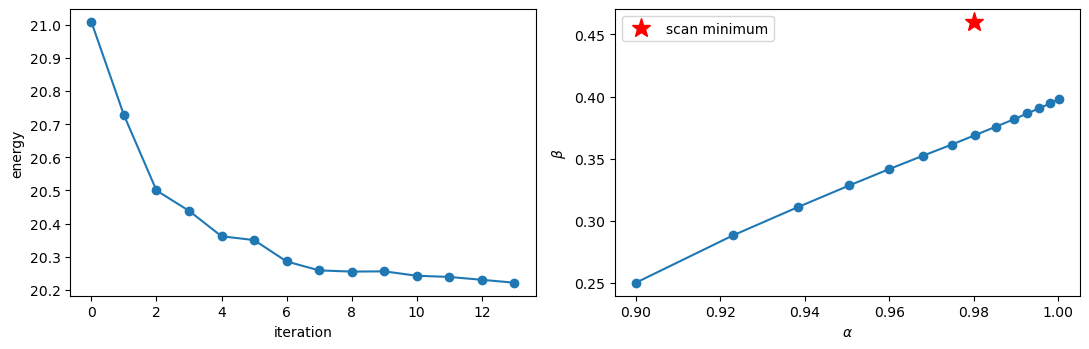

In [6]:
theta, history = mbmc.optimise(6, 0.90, 0.25, 1.0, learning_rate=0.004,
                               max_iter=14, tol=0.05, n_walkers=150,
                               n_steps=120, rng=np.random.default_rng(7),
                               verbose=True)
print(f"-> alpha = {theta[0]:.4f}, beta = {theta[1]:.4f}")

params = np.array([h[0] for h in history])
energies = np.array([h[1] for h in history])
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 3.6))
left.plot(energies, "o-")
left.set_xlabel("iteration"); left.set_ylabel("energy")
right.plot(params[:, 0], params[:, 1], "o-")
right.plot([0.98], [0.46], "r*", markersize=14, label="scan minimum")
right.set_xlabel(r"$\alpha$"); right.set_ylabel(r"$\beta$"); right.legend()
fig.tight_layout(); plt.show()

Refining on a scan puts the minimum at $\alpha = 0.98$, $\beta = 0.46$, with the
surface flat to $8\times10^{-3}$ over $\alpha\in[0.96,1.02]$.

That $\alpha$ comes out at 1 within the noise is the physically interesting part.
The optimal orbitals in the determinant are the *non-interacting* oscillator
eigenfunctions: the Jastrow factor absorbs the effect of the interaction on the
one-body part so completely that a scale parameter has nothing left to do.  Harju
and co-workers found the same for this system, and noted that it fails for three
electrons, where the spin populations differ.  Closed shells are forgiving.

## 6. Variational Monte Carlo

In [7]:
run = mbmc.vmc(6, 0.98, 0.46, 1.0, n_walkers=600, n_steps=900, burn_in=200,
               time_step=0.05, rng=np.random.default_rng(2024))
mean, error, k = blocking(run["series"])
print(f"E_VMC = {mean:.5f} +/- {error:.5f}   ({600*900} samples)")
print(f"  tau {correlation_time(run['series']):.2f}, "
      f"acceptance {run['acceptance']:.1%}, "
      f"spin exchanges accepted {run['spin_acceptance']:.1%}")
print(f"  CCSD in 42 orbitals (chapter 11): {REFERENCE[6]['ccsd']:.5f}")
print(f"  published DMC                   : 20.1597(2)")

E_VMC = 20.19961 +/- 0.00091   (540000 samples)
  tau 2.74, acceptance 97.4%, spin exchanges accepted 41.6%
  CCSD in 42 orbitals (chapter 11): 20.27325
  published DMC                   : 20.1597(2)


## 7. Diffusion Monte Carlo, and a warning

The spin-exchange move is exact in variational Monte Carlo and **wrong** in
diffusion Monte Carlo.  It satisfies detailed balance with respect to
$|\Psi_T|^2$, which is what VMC samples, and *not* with respect to
$f = \Psi_T\Phi$, which is what DMC samples.  Applied at every step it competes
with the branching and pulls the walkers back to the variational distribution.

This is not a small bias.

In [8]:
for spin_moves in ("always", "equilibration", "never"):
    out = mbmc.dmc(6, 0.98, 0.46, 1.0, n_walkers=200, n_steps=400, burn_in=300,
                   time_step=0.02, rng=np.random.default_rng(2024),
                   spin_moves=spin_moves)
    mean, error, _ = blocking(out["series"])
    print(f"spin_moves = {spin_moves:<14s} E = {mean:.5f} +/- {error:.5f}")

spin_moves = always         E = 20.19483 +/- 0.00321


spin_moves = equilibration  E = 20.14812 +/- 0.00507


spin_moves = never          E = 20.14980 +/- 0.00340


`"always"` returns the variational energy to within its error bar: the projection
has been undone.  The remedy is to exchange during the variational equilibration,
leaving each walker in a randomised assignment, and then freeze -- the ensemble
still averages over assignments and nothing interferes with the projection.

### The time step

Note that the equilibration is measured in *imaginary time*, not in steps.  At
$\Delta\tau = 0.01$ a fixed number of steps covers a tenth of the imaginary time
it does at $\Delta\tau = 0.1$, and a calculation that forgets this reports the
time-step error of its own unconverged projection.

In [9]:
# The full four-point scan is in manybodymc.py and takes a couple of minutes;
# two time steps are enough to see that there is nothing to see.
time_steps = [0.10, 0.02]
energies, errors = [], []
print(f"{'dt':>8s} {'energy':>12s} {'error':>10s} {'acceptance':>12s}")
for dt in time_steps:
    out = mbmc.dmc(6, 0.98, 0.46, 1.0, n_walkers=250, n_steps=500,
                   burn_in=max(120, int(5.0 / dt)), time_step=dt,
                   rng=np.random.default_rng(2024), spin_moves="never")
    mean, error, _ = blocking(out["series"])
    energies.append(mean); errors.append(error)
    print(f"{dt:8.3f} {mean:12.5f} {error:10.5f} {out['acceptance']:11.1%}")
print()
print("manybodymc.py, all four time steps, weighted mean: 20.16125 +/- 0.00151")
print("published (Lohne et al. 2011):                     20.1597(2)")

      dt       energy      error   acceptance


   0.100     20.16003    0.00230       94.3%


   0.020     20.15882    0.00327       99.2%

manybodymc.py, all four time steps, weighted mean: 20.16125 +/- 0.00151
published (Lohne et al. 2011):                     20.1597(2)


No time-step dependence survives the error bars, and the weighted mean agrees
with the published fixed-node result at one standard error.

## 8. The comparison

| method | energy | basis |
|---|---|---|
| Hartree-Fock | 20.72026 | 42 orbitals |
| MP2 | 20.30256 | 42 orbitals |
| CCSD | 20.27325 | 42 orbitals |
| CCSD | 20.1737 | 20 shells (Lohne et al.) |
| $\Lambda$-CCSD(T) | 20.1582 | 20 shells (Lohne et al.) |
| VMC, this chapter | 20.19961(91) | none |
| DMC, this chapter | 20.16125(151) | none |
| DMC, published | 20.1597(2) | none |

Three things, different in kind.

**The basis is the limitation, not the method.**  CCSD in 42 orbitals is 0.11
above CCSD in twenty shells; almost the whole apparent gap between coupled
cluster and Monte Carlo is that, not a failure of the cluster expansion.  Read
the other way: at convergence, $\Lambda$-CCSD(T) and diffusion Monte Carlo --
sharing no approximation whatever -- agree to $1.5\times10^{-3}$ on a system with
no exact solution.  That agreement is the real result, and neither method could
establish it alone.

**The Monte Carlo hierarchy behaves as advertised.**  VMC is an upper bound, DMC
improves on it by 0.038, and DMC is itself an upper bound because the nodes are
approximate.

**The remaining error is nodal.**  Both Monte Carlo numbers rest on a single
determinant of oscillator orbitals, whose node is the condition that three
same-spin electrons be collinear.  That was never optimised and, within this
ansatz, cannot be.  It is the last uncontrolled approximation in the book.

## 9. Dependence on the confinement

Running the full $\omega$ scan takes a few minutes, so the numbers below come
from `manybodymc.py` rather than from this notebook.  Parameters are
$\alpha = 0.98$, $\beta = 0.46\sqrt{\omega}$ -- the oscillator length is
$\omega^{-1/2}$, so that is the only scaling the Jastrow range needs.

| $\hbar\omega$ | HF | MP2 | CCSD | VMC | DMC |
|---|---|---|---|---|---|
| 0.25 | 7.39179 | 7.06226 | 7.03671 | 7.02274(89) | 6.98238(106) |
| 0.50 | 12.27150 | 11.89288 | 11.86345 | 11.82437(199) | 11.78488(116) |
| 1.00 | 20.72026 | 20.30256 | 20.27325 | 20.19961(91) | 20.15960(278) |
| 2.00 | 35.67233 | 35.22533 | 35.19959 | 35.09581(341) | 35.04162(394) |
| 4.00 | 62.74116 | 62.27348 | 62.25276 | 62.11527(657) | 62.05754(472) |

The ordering HF > MP2 > CCSD > VMC > DMC holds at every frequency, and the gap
between the coupled-cluster and Monte Carlo columns widens as $\omega$ falls
(0.014 at $\omega = 4$, 0.054 at $\omega = 0.25$): a shallow trap is more
strongly correlated and the finite basis is worse there.

**An honest discrepancy.**  At $\hbar\omega = 0.5$ the published DMC value is
11.7888(2) and the table gives 11.78488(116) -- *below* it, which is impossible
for two calculations sharing the same nodes, since fixed-node energies are upper
bounds.  The culprit is population control: repeating that point with 250 walkers
gives 11.77981(144) and with 800 gives 11.78543(149).  The energy climbs as the
population grows, which is the standard signature and direction of
population-control bias.  At $\hbar\omega = 1$ the same test finds no movement
between 100 and 400 walkers, because the local energy fluctuates less and the
branching is gentler.  The bias is $O(1/N_{\rm walkers})$ and would be removed by
larger populations; it is left visible because a residual of $4\times10^{-3}$ is
exactly what a table of six-digit numbers is apt to conceal.

## 10. Two pictures of the six-electron dot

The sections above report numbers.  The two figures here show what the numbers
are made of.  Both come from short runs -- a few hundred sweeps with a couple of
hundred walkers -- which is enough to show the behaviour and nowhere near enough
for a production error bar.

### The local energy along a run

Every variational average in this notebook is the mean of a time series, and the
series has two parts which must be kept apart.  The walkers start life in a
Gaussian cloud that is *not* distributed as $|\Psi_T|^2$, so the first few tens
of sweeps carry a transient; after that the series fluctuates about a plateau,
and the only remaining question is how strongly successive sweeps are
correlated.  The run below is started with `burn_in=0` precisely so that the
transient is kept and can be looked at, rather than discarded silently.

plateau after discarding 100 sweeps: 20.1968 +/- 0.0024
  correlation time tau = 3.87 sweeps, acceptance 97.4%
  running mean including the burn-in at sweep 100: 20.1940   (-0.0028)
  running mean including the burn-in at sweep 200: 20.1963   (-0.0005)
  running mean including the burn-in at sweep 400: 20.1969   (+0.0001)
  running mean including the burn-in at sweep 700: 20.1964   (-0.0004)


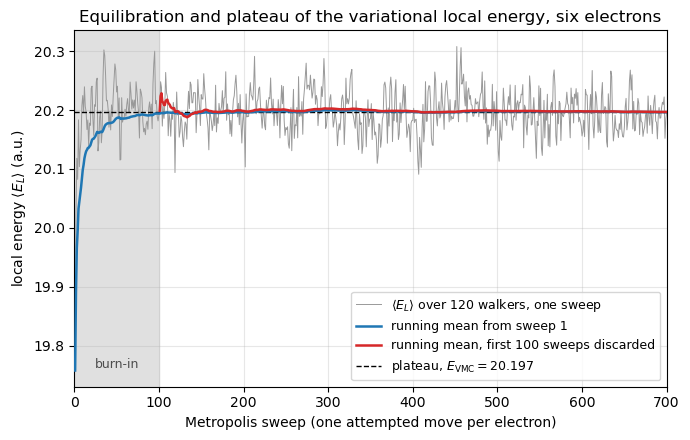

In [10]:
trace = mbmc.vmc(6, 0.98, 0.46, 1.0, n_walkers=120, n_steps=700, burn_in=0,
                 time_step=0.05, rng=np.random.default_rng(2024))
series = trace["series"]
sweeps = np.arange(1, series.size + 1)
running = np.cumsum(series) / sweeps

discard = 100
tail = series[discard:]
running_tail = np.cumsum(tail) / np.arange(1, tail.size + 1)
plateau, error, _ = blocking(tail)
print(f"plateau after discarding {discard} sweeps: {plateau:.4f} +/- {error:.4f}")
print(f"  correlation time tau = {correlation_time(tail):.2f} sweeps, "
      f"acceptance {trace['acceptance']:.1%}")
for k in (100, 200, 400, 700):
    print(f"  running mean including the burn-in at sweep {k:3d}: "
          f"{running[k-1]:.4f}   ({running[k-1] - plateau:+.4f})")

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.axvspan(0, discard, color="0.88", zorder=0)
ax.plot(sweeps, series, color="0.6", lw=0.7, zorder=1,
        label=r"$\langle E_L\rangle$ over 120 walkers, one sweep")
ax.plot(sweeps, running, "C0-", lw=1.8, zorder=3,
        label="running mean from sweep 1")
ax.plot(sweeps[discard:], running_tail, "C3-", lw=1.8, zorder=3,
        label=f"running mean, first {discard} sweeps discarded")
ax.axhline(plateau, color="k", ls="--", lw=1.0, zorder=2,
           label=fr"plateau, $E_{{\rm VMC}} = {plateau:.3f}$")
ax.text(discard / 2, series.min(), "burn-in", ha="center", va="bottom",
        fontsize=9, color="0.3")
ax.set_xlim(0, series.size)
ax.set_xlabel("Metropolis sweep (one attempted move per electron)")
ax.set_ylabel(r"local energy $\langle E_L\rangle$ (a.u.)")
ax.set_title("Equilibration and plateau of the variational local energy, "
             "six electrons")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

The transient is over in some thirty sweeps, and the two running means say what
discarding it is worth: the mean that keeps the burn-in is still about one
standard error low at sweep 100 and is indistinguishable from the plateau by
sweep 400.  That the effect is this small is luck rather than virtue -- the
initial Gaussian cloud happens to be a fair approximation to $|\Psi_T|^2$ for a
trap of $\hbar\omega = 1$ -- and the same picture drawn for a shallow trap, or
from a deliberately bad start, would show a transient worth many error bars.

The grey curve also shows why the error bar cannot be read off the scatter.
`correlation_time` returns $\tau = 1 + 2\sum_d\kappa_d \approx 3.9$, so the naive
standard error of $N$ points understates the true one by $\sqrt{\tau}\approx 2$;
that is what `blocking` is for, and it is the reason every number in this
notebook is quoted through it.

### The Jastrow factor, seen

The Jastrow factor is usually justified by what it does to the energy.  It is
more instructive to look at what it does to the electrons.  We sample the same
six-electron dot twice, with the same importance-sampled sweep and the same
seed: once from $|D_\uparrow D_\downarrow|^2$ alone -- the bare determinant of
oscillator orbitals, obtained by setting every cusp coefficient $a_{ij}$ to zero
-- and once from the full $|\Psi_T|^2$.  Nothing else differs.

Slater determinant alone    <r> = 1.1932   <r_ij> = 1.7496


Slater-Jastrow              <r> = 1.5104   <r_ij> = 2.2643


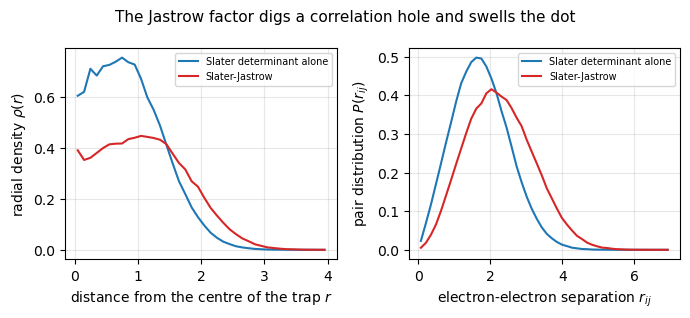

In [11]:
class DeterminantOnly(mbmc.Ensemble):
    """The same ensemble with the Jastrow factor switched off, $a_{ij} = 0$."""

    def _cusp(self, spins):
        return np.zeros(spins.shape + (spins.shape[1],))


def collect(ens, n_steps=300, burn_in=60, time_step=0.05, every=4, seed=11):
    """Sweep with the chapter's own drifting move, binning radii and pair
    separations every few sweeps.  A short run, enough to show the behaviour."""
    rng = np.random.default_rng(seed)
    positions, spins = ens.positions.copy(), ens.spins.copy()
    log_psi = ens.log_psi(positions, spins)
    force = ens.quantum_force(positions, spins)
    upper = np.triu_indices(ens.N, 1)
    radii, separations = [], []
    for step in range(burn_in + n_steps):
        positions, log_psi, force, _, _, _ = mbmc._spatial_sweep(
            ens, positions, spins, log_psi, force, time_step, rng)
        if step >= burn_in and step % every == 0:
            radii.append(np.linalg.norm(positions, axis=2).ravel())
            delta = positions[:, :, None, :] - positions[:, None, :, :]
            separations.append(
                np.linalg.norm(delta, axis=-1)[:, upper[0], upper[1]].ravel())
    return np.concatenate(radii), np.concatenate(separations)


samples = {}
for label, factory in (("Slater determinant alone", DeterminantOnly),
                       ("Slater-Jastrow", mbmc.Ensemble)):
    ens = factory(250, 6, 0.98, 0.46, 1.0, np.random.default_rng(2024))
    samples[label] = collect(ens)
    r, s = samples[label]
    print(f"{label:<26s}  <r> = {r.mean():.4f}   <r_ij> = {s.mean():.4f}")

edges = np.linspace(0.0, 4.0, 41)
centres = 0.5 * (edges[1:] + edges[:-1])
rings = np.pi * (edges[1:] ** 2 - edges[:-1] ** 2)
pair_edges = np.linspace(0.0, 7.0, 51)
pair_centres = 0.5 * (pair_edges[1:] + pair_edges[:-1])

fig, (left, right) = plt.subplots(1, 2, figsize=(7.0, 3.2))
for (label, (r, s)), colour in zip(samples.items(), ("C0", "C3")):
    counts, _ = np.histogram(r, bins=edges)
    left.plot(centres, 6.0 * counts / counts.sum() / rings, colour, label=label)
    height, _ = np.histogram(s, bins=pair_edges, density=True)
    right.plot(pair_centres, height, colour, label=label)
left.set_xlabel(r"distance from the centre of the trap $r$")
left.set_ylabel(r"radial density $\rho(r)$")
left.legend(fontsize=7)
left.grid(alpha=0.3)
right.set_xlabel(r"electron-electron separation $r_{ij}$")
right.set_ylabel(r"pair distribution $P(r_{ij})$")
right.legend(fontsize=7)
right.grid(alpha=0.3)
fig.suptitle("The Jastrow factor digs a correlation hole and swells the dot",
             fontsize=11)
fig.tight_layout()
plt.show()

The two panels are the same effect seen twice.  The Jastrow factor suppresses
configurations in which two electrons are close: the pair distribution loses its
weight below $r_{ij}\approx 2$ and gains it above, and the mean separation goes
from 1.75 to 2.26.  Since the electrons keep out of each other's way by moving
outwards, the density flattens and spreads and the mean radius grows from 1.19
to 1.51 -- the dot swells by a quarter, at fixed confinement, purely from
correlation.

The determinant alone cannot do this.  It keeps *parallel* spins apart, which is
the exchange hole and is already in the blue curves; what it says about an up
and a down electron meeting is nothing at all.  That is the gap
$a_{\uparrow\downarrow} = 1$ is there to fill, and the reason the cusp
coefficients of section 3 had to be spin dependent.